In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('statistics_sales_project_data.csv')
df.head()

,date,store_type,region,marketing_campaign,units_sold,revenue
0,2023-01-01,Online,Western,Yes,6,11876.03
1,2023-01-02,Physical,Rift Valley,Yes,8,14333.00
2,2023-01-03,Physical,Western,No,4,8101.97
3,2023-01-04,Physical,Coast,No,8,10928.92
4,2023-01-05,Online,Nairobi,No,9,18166.40


In [3]:
df.describe()

,units_sold,revenue
count,1200.000000,1200.000000
mean,4.976667,8271.974000
std,2.271289,4279.961469
min,0.000000,0.000000
25%,3.000000,5177.527500
50%,5.000000,7723.325000
75%,6.000000,10739.320000
max,15.000000,26885.870000


In [4]:
print(df['revenue'].mean())
print(df['revenue'].median())
print(df['revenue'].mode())

8271.974
7723.325
0    0.0
Name: revenue, dtype: float64


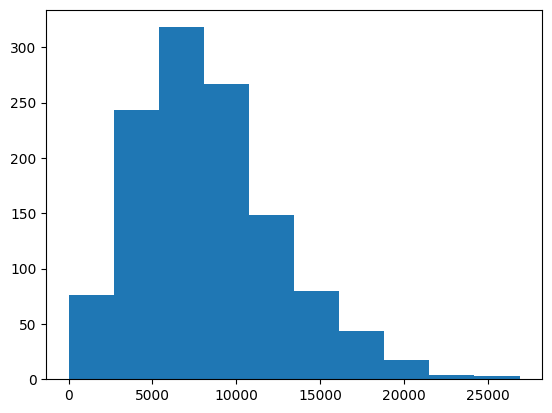

In [5]:
plt.hist(df['revenue']);

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                1200 non-null   object 
 1   store_type          1200 non-null   object 
 2   region              1200 non-null   object 
 3   marketing_campaign  1200 non-null   object 
 4   units_sold          1200 non-null   int64  
 5   revenue             1200 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 56.4+ KB


In [7]:
df['date']= pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                1200 non-null   datetime64[ns]
 1   store_type          1200 non-null   object        
 2   region              1200 non-null   object        
 3   marketing_campaign  1200 non-null   object        
 4   units_sold          1200 non-null   int64         
 5   revenue             1200 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 56.4+ KB


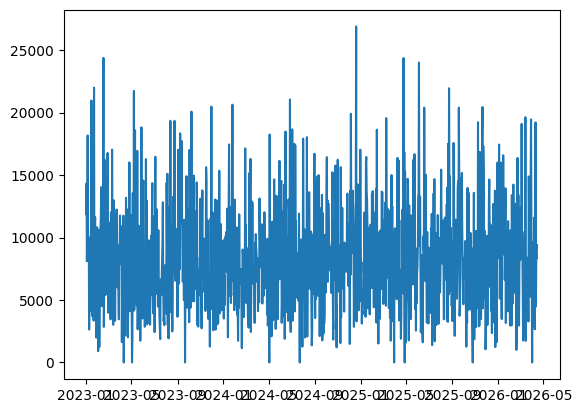

In [8]:
plt.plot(df['date'],df['revenue'])

<BarContainer object of 1200 artists>

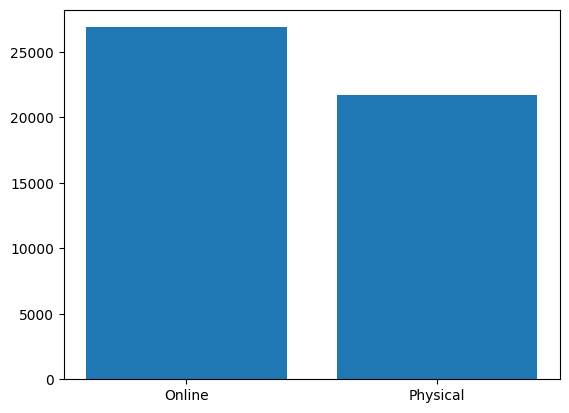

In [9]:
plt.bar(df['store_type'], df['revenue'])

<Axes: xlabel='region', ylabel='revenue'>

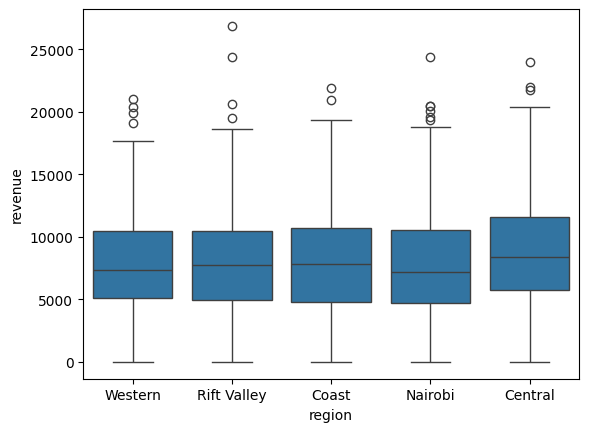

In [10]:
sns.boxplot(data= df , x='region', y='revenue')

Population and Sample:  
The population consists of all possible sales transactions made by the company, while the dataset used in the project represents a sample drawn from that population

Assuming: Only urban stores were sampled  
What bias exists?  
Selection bias because only urban stores were included so the dataset does not include the full business environment.  

How would it affect conclusions? 
The analysis would be misleading since it would overestimate performance.  
Wrong business decisions about demand forecasting  

Propose a better sampling method.
stratified random sampling, where stores are grouped by region type and sampled proportionally to ensure full market representation.

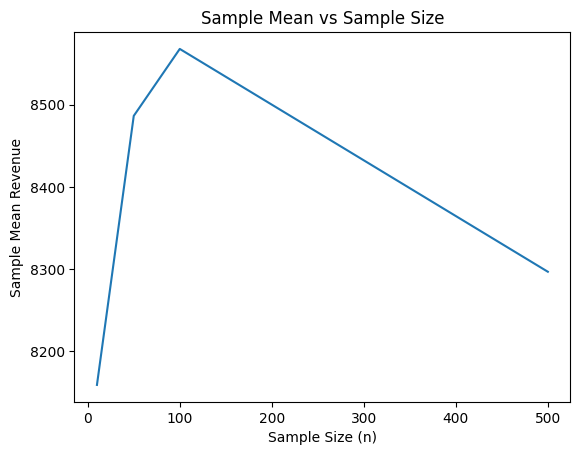

In [11]:
revenue = df['revenue']
sample_sizes = [10,50,100,500]
sample_means = []

for n in sample_sizes:
    sample = revenue.sample(n=n, random_state=42)
    sample_means.append(sample.mean())
sample_means

plt.plot(sample_sizes , sample_means)
plt.xlabel("Sample Size (n)")
plt.ylabel("Sample Mean Revenue")
plt.title("Sample Mean vs Sample Size")
plt.show()

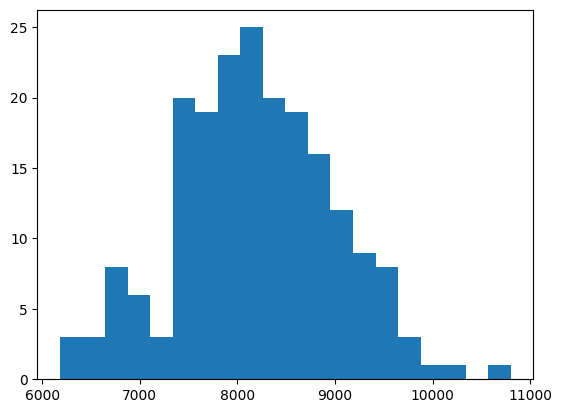

In [12]:
num_samples = 200
sample_size = 30

sample_means =[]
for i in range(num_samples):
    sample = revenue.sample(n=sample_size, replace = True)
    sample_means.append(sample.mean())


plt.hist(sample_means, bins=20);

In [13]:
(df['marketing_campaign']).value_counts()

marketing_campaign
No     753
Yes    447
Name: count, dtype: int64

In [14]:
no_campaign = df[df['marketing_campaign'] == 'No']['revenue']
no_campaign.shape

(753,)

In [15]:
campaign = df[df['marketing_campaign'] == 'Yes']['revenue']
campaign.shape

(447,)

In [16]:
campaign.mean()

np.float64(8977.578993288591)

In [17]:
no_campaign.mean()

np.float64(7853.108884462152)

In [18]:
from scipy import stats

In [19]:
t_stat, p_value = stats.ttest_ind(campaign, no_campaign)
t_stat, p_value

(np.float64(4.434274857534006), np.float64(1.0086083638101027e-05))

In [20]:
p_value_one = p_value/2
p_value_one

np.float64(5.043041819050514e-06)

In [21]:
'{:f}'.format(p_value_one)

'0.000005'

Since the p-value is less than 0.05, we reject the null hypothesis and conclude that the marketing campaign significantly increases mean revenue. 

Type I error is when the null hypothesis is true but is incorrectly rejected.
In this context, the company would believe that compaign increases revenue when it actually doesn't.

Type II error ooccurs when a null hypothesis is not rejected even though it is actually false.
In this context, the company would stop or avoid using compaign when it does actually work and that will affect sales and revenue